# Foundation Models Sandbox: Comparing CausalPFN, Do-PFN & CausalFM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/layer6ai-labs/causalfm-survey/blob/main/notebooks/Foundation_models_sandbox.ipynb)

**Compares all three causal foundation models side by side on the same
dataset** (CausalPFN, Do-PFN, and CausalFM), each runs through its own native
API, with results and a comparison plot at the end.

If you just want one model running as fast as possible, see
[`Foundation_models_quickstart.ipynb`](Foundation_models_quickstart.ipynb)
(CausalPFN alone, end to end).

This notebook is standalone — it doesn't import this repo's `causal_bench`
wrappers. Every call below is exactly what you'd write reading each model's
own README, so you can lift a cell straight into your own project.

**Run this on Colab** (badge above) — everything installs automatically.
Running locally needs more manual setup; see "Running locally" at the end.

| Step | What it does |
|---|---|
| §0 | One-time environment check — **run this first** if you want Do-PFN to work |
| §1 | Generate a synthetic dataset with a known treatment effect |
| §2 | Run **CausalPFN** — `pip install causalpfn`, native `CATEEstimator` / `ATEEstimator` |
| §3 | Run **Do-PFN** — `git clone`, native `DoPFNRegressor` |
| §4 | Run **CausalFM** — `git clone` + checkpoint, native `StandardCATEModel` |
| §5 | Compare all three against ground truth |

## What's special about causal foundation models?

CausalPFN, Do-PFN and CausalFM are **amortized** / **in-context** estimators: a
single transformer is pretrained once (by the model authors, on millions of
synthetic causal-inference problems) and shipped as frozen weights. There's no
per-dataset training loop on your end — `fit()` just loads your data as
**context** for a forward pass over a **query** set.

```python
# Traditional metalearner (e.g. T-learner): trains fresh parameters on YOUR data
model_treated = RandomForest().fit(X_train[T_train == 1], Y_train[T_train == 1])
model_control = RandomForest().fit(X_train[T_train == 0], Y_train[T_train == 0])
tau_hat = model_treated.predict(X_test) - model_control.predict(X_test)

# Causal foundation model: weights are already trained; "fit" just stores context
cate_estimator = CATEEstimator(device=device)  # pretrained weights, downloaded once
cate_estimator.fit(X_ctx, T_ctx, Y_ctx)  # NO gradient descent on your data
tau_hat = cate_estimator.estimate_cate(X_qry)  # one forward pass over the query set
```

**Practical upshot:** `fit()` is cheap, and no further training is required
for each new dataset. 
<!-- The three models below differ mainly in how you get
their weights (PyPI vs. `git clone`) and the exact shape of their
`fit`/`predict` calls. -->

## 0. One-time environment check for Do-PFN

Only needed for Do-PFN (§3): its model code depends on an internal PyTorch
name removed in `torch>=2.10`. Skip this if you're not running that section.

In [1]:
import sys, importlib.metadata

IN_COLAB = "google.colab" in sys.modules
TORCH_PIN = "2.9.1"  # last version verified compatible with Do-PFN

def _torch_needs_downgrade():
    try:
        v = importlib.metadata.version("torch")
    except importlib.metadata.PackageNotFoundError:
        return False
    major, minor = (int(p) for p in v.split("+")[0].split(".")[:2])
    return (major, minor) >= (2, 10)

if not _torch_needs_downgrade():
    print("OK -- torch is compatible with Do-PFN (or not installed yet).")
elif IN_COLAB:
    print(f"Installing torch=={TORCH_PIN} for Do-PFN compatibility (can take a minute)...")
    get_ipython().system(f"pip install -q torch=={TORCH_PIN}")
else:
    print(f'torch>=2.10 detected -- Do-PFN needs torch=={TORCH_PIN}. '
          f'Run uv pip install "torch=={TORCH_PIN}" in a terminal, then restart the kernel and re-run this notebook.')

OK -- torch is compatible with Do-PFN (or not installed yet).


## 1. Example dataset — a simulated discount-email campaign

An online retailer sends a discount email to a subset of customers and wants
to know its effect on next-month spend.

- **Covariates**: `recency` (days since last purchase, standardized), `monetary`
  (average past order value, standardized), `age` (standardized).
- **Treatment** `T`: received the discount email — **confounded on purpose**:
  marketing targets loyal, high-spend, recently-active customers, so a naive
  treated-vs-untreated comparison is biased.
- **Outcome** `Y`: next-month spend.
- **Ground truth** (known only because this is simulated): the email works
  *better* on lapsed customers and *worse* on older ones —
  `tau(x) = 2.0 + 1.5 * recency - 0.75 * age`, a heterogeneous effect that
  lets us score each model's CATE estimate, not just its ATE.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
rng = np.random.default_rng(SEED)
n = 1500

recency, monetary, age = rng.normal(0, 1, (3, n)).astype(np.float32)
X = np.column_stack([recency, monetary, age])

# Confounded treatment assignment: loyal, high-spend, recently-active
# customers are more likely to be targeted with the discount email.
propensity = 1 / (1 + np.exp(-(0.8 * monetary - 0.6 * recency)))
T = rng.binomial(1, propensity).astype(np.float32)

true_cate = (2.0 + 1.5 * recency - 0.75 * age).astype(np.float32)  # unobservable outside a simulation
noise = rng.normal(0, 1.0, n).astype(np.float32)
Y0 = (5.0 + 2.0 * monetary - 0.5 * age + noise).astype(np.float32)
Y = np.where(T == 1, Y0 + true_cate, Y0).astype(np.float32)

# ctx: what each model conditions on. qry: points to predict for. There's no
# training step, so this is a context/query split, not a train/test split.
X_ctx, X_qry, T_ctx, T_qry, Y_ctx, Y_qry, _, cate_qry = train_test_split(
    X, T, Y, true_cate, test_size=0.3, random_state=SEED
)
true_ate = float(true_cate.mean())

print(f"n_ctx / n_qry                  : {len(X_ctx)} / {len(X_qry)}")
print(f"Naive treated-vs-control gap   : {Y[T == 1].mean() - Y[T == 0].mean():.3f}  (biased by confounding)")
print(f"True ATE (known only here)     : {true_ate:.3f}")

n_ctx / n_qry                  : 1050 / 450
Naive treated-vs-control gap   : 3.209  (biased by confounding)
True ATE (known only here)     : 1.967


In [3]:
# Scoring helpers
import os, sys, time, torch

def pehe(cate_hat, cate_ref):
    return float(np.sqrt(np.mean((np.asarray(cate_hat) - np.asarray(cate_ref)) ** 2)))

def ate_abs_error(ate_hat, ate_ref):
    return float(abs(ate_hat - ate_ref))

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

results = {}  # model name -> dict(tau_hat, ate_hat, runtime, pehe, ate_abs_error)

Device: mps


## 2. CausalPFN

**Install:** `pip install causalpfn` — a normal PyPI package. The first call
downloads pretrained weights from the Hugging Face Hub (a few hundred MB), so
it needs internet access once; after that they're cached locally.

**Caveat:** on Apple Silicon macOS, CausalPFN segfaults on both CPU and MPS.
Expected to run fine on Colab (either GPU or CPU).

In [4]:
import importlib.util
if importlib.util.find_spec("causalpfn") is None:
    %pip install -q causalpfn
import platform

APPLE_SILICON_MACOS = platform.system() == "Darwin" and platform.machine() == "arm64"

if device != "cuda" and APPLE_SILICON_MACOS:
    print("Skipping CausalPFN: segfaults on Apple Silicon macOS -- works fine on Colab.")
else:
    from causalpfn import CATEEstimator, ATEEstimator

    t0 = time.time()
    cate_hat = np.asarray(
        CATEEstimator(device=device, verbose=False).fit(X_ctx, T_ctx, Y_ctx).estimate_cate(X_qry)
    ).reshape(-1)
    ate_hat = float(np.asarray(
        ATEEstimator(device=device, verbose=False).fit(X_ctx, T_ctx, Y_ctx).estimate_ate()
    ).reshape(-1)[0])
    runtime = time.time() - t0

    results["CausalPFN"] = dict(
        tau_hat=cate_hat, ate_hat=ate_hat, runtime=runtime,
        pehe=pehe(cate_hat, cate_qry), ate_abs_error=ate_abs_error(ate_hat, true_ate),
    )

Skipping CausalPFN: segfaults on Apple Silicon macOS -- works fine on Colab.


In [5]:
if "CausalPFN" in results:
    r = results["CausalPFN"]
    print(f"CausalPFN | PEHE={r['pehe']:.3f}  ATE_hat={r['ate_hat']:.3f}  runtime={r['runtime']:.2f}s")

## 3. Do-PFN

Do-PFN isn't on PyPI, so we clone the repo directly.

If you hit `ImportError: cannot import name 'Optional' from 'torch.nn.modules.transformer'`,
run section 0 above first.

In [6]:
import subprocess

DOPFN_DIR = "Do-PFN"
if not os.path.exists(DOPFN_DIR):
    subprocess.run(["git", "clone", "https://github.com/jr2021/Do-PFN.git"], check=True)
sys.path.insert(0, os.path.abspath(DOPFN_DIR))

if IN_COLAB:
    get_ipython().system("pip install -q networkx tqdm einops")

try:
    from scripts.transformer_prediction_interface import DoPFNRegressor

    # Treatment goes in column 0.
    X_full_ctx = np.concatenate([T_ctx.reshape(-1, 1), X_ctx], axis=1)
    X_full_qry = np.concatenate(
        [np.zeros((len(X_qry), 1), dtype=np.float32), X_qry], axis=1
    )  # column 0 here is a placeholder; predict_cate overwrites it internally

    t0 = time.time()
    _cwd = os.getcwd()
    os.chdir(DOPFN_DIR)
    try:
        dopfn = DoPFNRegressor()
        dopfn.show_progress = False
        dopfn.fit(X_full_ctx, Y_ctx)
        cate_hat = np.asarray(dopfn.predict_cate(torch.as_tensor(X_full_qry))).reshape(-1)
    finally:
        os.chdir(_cwd)
    runtime = time.time() - t0

    ate_hat = float(cate_hat.mean())
    results["Do-PFN"] = dict(
        tau_hat=cate_hat, ate_hat=ate_hat, runtime=runtime,
        pehe=pehe(cate_hat, cate_qry), ate_abs_error=ate_abs_error(ate_hat, true_ate),
    )
except Exception as e:
    print(f"Do-PFN failed: {e}")
    if "torch.nn.modules.transformer" in str(e):
        print("Torch version mismatch -- run section 0 above, restart the kernel, then re-run from the top.")

Changed model to be compatible with CPU, this is needed for the current version of PyTorch, see issue: https://github.com/pytorch/pytorch/issues/97128. The model will be slower if reused on GPU.


/Users/hosseinrahmani/Documents/Causal_FM_Survey/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hosseinrahmani/Documents/Causal_FM_Survey/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hosseinrahmani/Documents/Causal_FM_Survey/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hosseinrahmani/Documents/Causal_FM_Survey/notebooks/Do-PFN/scripts/transformer_prediction_interface/base.py:1497: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=

In [7]:
if "Do-PFN" in results:
    r = results["Do-PFN"]
    print(f"Do-PFN | PEHE={r['pehe']:.3f}  ATE_hat={r['ate_hat']:.3f}  runtime={r['runtime']:.2f}s")

Do-PFN | PEHE=1.407  ATE_hat=1.652  runtime=0.76s


## 4. CausalFM

Also not on PyPI, so we clone the repo directly.

In [8]:
CAUSALFM_DIR = "CausalFM-toolkit"
CAUSALFM_CHECKPOINT = f"{CAUSALFM_DIR}/checkpoints/checkpoints_standard/best_model.pth"  # not checkpoints/best_model.pth, despite the toolkit's own README

if not os.path.exists(CAUSALFM_DIR):
    subprocess.run(["git", "clone", "https://github.com/yccm/CausalFM-toolkit.git"], check=True)
sys.path.insert(0, os.path.abspath(CAUSALFM_DIR))

if IN_COLAB:
    get_ipython().system('pip install -q einops "tabpfn==2.0.9" tensorboard')

from causalfm.models import StandardCATEModel

if not os.path.exists(CAUSALFM_CHECKPOINT):
    print(f"Checkpoint not found at {CAUSALFM_CHECKPOINT}")
else:
    t0 = time.time()
    model = StandardCATEModel.from_pretrained(CAUSALFM_CHECKPOINT)

    X_ctx_t = torch.as_tensor(X_ctx, dtype=torch.float32)
    T_ctx_t = torch.as_tensor(T_ctx, dtype=torch.float32).reshape(-1, 1)
    Y_ctx_t = torch.as_tensor(Y_ctx, dtype=torch.float32).reshape(-1, 1)
    X_qry_t = torch.as_tensor(X_qry, dtype=torch.float32)

    cate_hat = model.estimate_cate(X_ctx_t, T_ctx_t, Y_ctx_t, X_qry_t)["cate"].detach().cpu().numpy().reshape(-1)
    runtime = time.time() - t0

    ate_hat = float(cate_hat.mean())
    results["CausalFM"] = dict(
        tau_hat=cate_hat, ate_hat=ate_hat, runtime=runtime,
        pehe=pehe(cate_hat, cate_qry), ate_abs_error=ate_abs_error(ate_hat, true_ate),
    )

Model loaded from CausalFM-toolkit/checkpoints/checkpoints_standard/best_model.pth


In [9]:
if "CausalFM" in results:
    r = results["CausalFM"]
    print(f"CausalFM | PEHE={r['pehe']:.3f}  ATE_hat={r['ate_hat']:.3f}  runtime={r['runtime']:.2f}s")

CausalFM | PEHE=2.194  ATE_hat=0.646  runtime=0.57s


## 5. Compare & visualize

Whatever subset of the three models ran successfully in your environment gets
plotted here — left panel: estimated CATE vs. ground truth (perfect
predictions sit on the diagonal); right panel: PEHE per model (lower is
better).

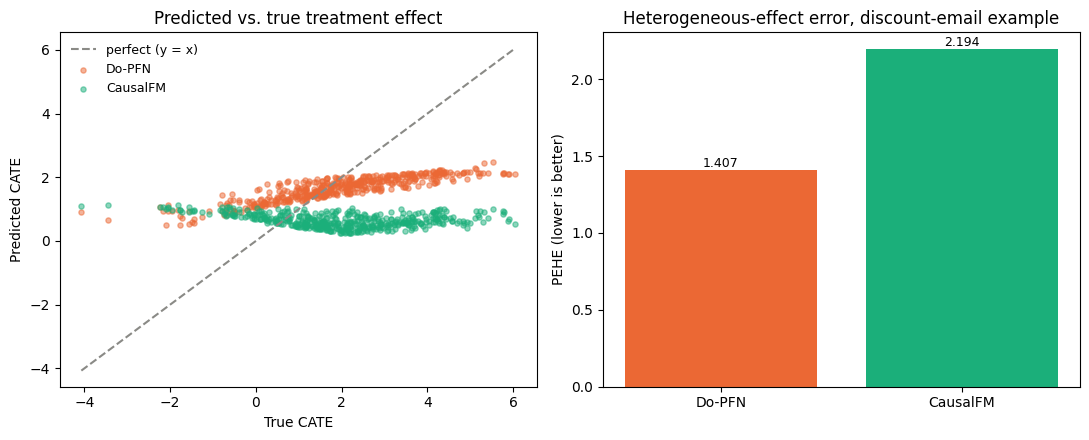

          ATE_hat  True_ATE   PEHE  ATE_abs_error  Runtime (s)
Do-PFN      1.652     1.967  1.407          0.314        0.758
CausalFM    0.646     1.967  2.194          1.320        0.570


In [11]:
import matplotlib.pyplot as plt

MODEL_COLORS = {"CausalPFN": "#2a78d6", "Do-PFN": "#eb6834", "CausalFM": "#1baf7a"}

if not results:
    print("No foundation model ran successfully in this environment -- "
          "see the messages above for what to install.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ax = axes[0]
    lo = min(cate_qry.min(), *[r["tau_hat"].min() for r in results.values()])
    hi = max(cate_qry.max(), *[r["tau_hat"].max() for r in results.values()])
    ax.plot([lo, hi], [lo, hi], color="#8a8a86", linewidth=1.5, linestyle="--", label="perfect (y = x)")
    for name, r in results.items():
        ax.scatter(cate_qry, r["tau_hat"], s=14, alpha=0.5, color=MODEL_COLORS[name], label=name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Predicted CATE")
    ax.set_title("Predicted vs. true treatment effect")
    ax.legend(frameon=False, fontsize=9)

    ax = axes[1]
    names = list(results.keys())
    pehes = [results[n]["pehe"] for n in names]
    ax.bar(names, pehes, color=[MODEL_COLORS[n] for n in names])
    for i, v in enumerate(pehes):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("PEHE (lower is better)")
    ax.set_title("Heterogeneous-effect error, discount-email example")

    plt.tight_layout()
    plt.savefig("foundation_models_sandbox.png", dpi=150)
    plt.show()

    summary = pd.DataFrame({
        name: {"ATE_hat": r["ate_hat"], "True_ATE": true_ate, "PEHE": r["pehe"],
               "ATE_abs_error": r["ate_abs_error"], "Runtime (s)": r["runtime"]}
        for name, r in results.items()
    }).T
    print(summary.round(3))

## Reference output — verified successful run (Colab, GPU runtime)

If your numbers look like this, your setup is correct. Fixed `SEED = 42`
makes the dataset and context/query split identical every run, so `True_ATE`
will always read **1.967** — differences beyond that come from the usual
sources of nondeterminism in the models themselves (GPU non-determinism,
library version drift, CPU vs. GPU execution), not from your setup being
wrong.

| Model | ATE_hat | True_ATE | PEHE | ATE_abs_error | Runtime (s) |
|---|---|---|---|---|---|
| CausalPFN | 1.911 | 1.967 | 0.237 | 0.056 | 10.059 |
| Do-PFN | 1.652 | 1.967 | 1.407 | 0.314 | 8.264 |
| CausalFM | 0.646 | 1.967 | 2.194 | 1.320 | 0.311 |

![Reference plot: predicted vs. true CATE, and PEHE per model](assets/reference_output_colab.png)

**CausalPFN** (blue) tracks the true CATE closely across its full range,
hugging the `y = x` diagonal. **Do-PFN** (orange) gets the direction right but
compresses the range, under-predicting the largest true effects. **CausalFM**
(green) clusters its predictions in a narrow band regardless of the true
effect size, posting the worst PEHE and ATE error of the three here.

## Running locally instead of Colab

This notebook is built to just work on Colab — every install cell above
handles itself automatically. To run it locally instead, in a terminal:

- CausalPFN: `uv pip install causalpfn`
- Do-PFN: `uv pip install networkx tqdm einops`, plus `uv pip install "torch==2.9.1"`
  if section 0 above flagged a torch version mismatch
- CausalFM: `uv pip install einops "tabpfn==2.0.9" tensorboard`

This repo's local `uv`-managed venv has no `pip` module, so the
`%pip install` / `!pip install` cells above silently no-op locally — that's
why each install still needs to happen manually first.

**Apple Silicon Macs**: CausalPFN segfaults on both CPU and MPS — the cell
above detects this and skips automatically. Do-PFN and CausalFM both run
fine on CPU, just slower than on a GPU.